<div style="background-color:#0074D9; padding:12px; border-radius:6px;">
    <span style="color:white; font-weight:bold; font-size:16px;">
        This is 1 of 2 Pre-Processiong & Modeling workbooks.  This one is for the Customer Segmentation Model.
    </span>
</div>

<div style="background-color:lightblue; padding:12px; border-radius:6px;">
    <span style="color:black; font-size:16px;">
        This notebook documents the end-to-end pre-processing and modeling workflow used to develop a customer segmentation for Capstone 3. Starting from the finalized EDA feature set, the data was log-transformed where appropriate, standardized, and reduced using Principal Component Analysis (PCA) to remove redundancy and noise while preserving the majority of behavioral variance. Multiple clustering approaches (K-Means, Agglomerative, and DBSCAN) were evaluated using internal validation metrics and visual diagnostics. The final segmentation was selected based on cluster quality, interpretability, and business relevance, and cluster assignments were mapped back to individual customers to enable downstream profiling and activation. This notebook establishes the analytical foundation for the cluster insights and recommendations presented in subsequent analyses.
    </span>
</div>

In [1]:
# Imports and set-ups

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

RANDOM_STATE = 42

In [2]:
# Load data

customer_model_df = pd.read_csv('data/customer_segmentation_eda.csv')

## PRE PROCESSING

### 1. Define Features & Create Working Copy

In [3]:
# 1 DEFINE FEATURES & CREATE WORKING COPY

# Working copy
cust_df = customer_model_df.copy()

# ID column (kept for mapping only, NOT used in PCA/clustering)
id_col = "customer_id"
cust_df["category_variety"] = (cust_df["n_categories_purchased"] /cust_df["n_products_purchased"].replace(0, np.nan)).fillna(0)

# RFM features
rfm_features = [
    "recency_days",
    "n_orders",
    "total_revenue"
]

# Engagement features
engagement_features = [
    "n_events",
    "n_views",
    "n_add_to_cart",
    "n_sessions_with_events"
]

# Variety features
variety_features = [
    "n_products_purchased",
    "n_categories_purchased",
    "category_variety"
]

# Rate (0–1) features – DO NOT log-transform
rate_features = [
    "cart_to_view_rate",
    "purchase_to_cart_rate"
]

# All raw modeling features
all_model_features = (
    rfm_features
    + engagement_features
    + variety_features
    + rate_features
)

print("Number of raw modeling features:", len(all_model_features))

Number of raw modeling features: 12


### 2. Log-transform Skewed Continuous Features

In [4]:
# 2 LOG-TRANSFORM SKEWED CONTINUOUS FEATURES

# Features to log-transform (all non-rate quantitative fields)
log_features = rfm_features + engagement_features + variety_features

for col in log_features:
    new_col = col + "_log"
    # Clip at 0 to avoid weird negatives, then log1p
    cust_df[new_col] = np.log1p(cust_df[col].clip(lower=0))

log_feature_cols = [col + "_log" for col in log_features]

# Final transformed features for modeling
transformed_features = log_feature_cols + rate_features

print("Transformed features to use in scaling/PCA/clustering:")
for f in transformed_features:
    print("  -", f)

Transformed features to use in scaling/PCA/clustering:
  - recency_days_log
  - n_orders_log
  - total_revenue_log
  - n_events_log
  - n_views_log
  - n_add_to_cart_log
  - n_sessions_with_events_log
  - n_products_purchased_log
  - n_categories_purchased_log
  - category_variety_log
  - cart_to_view_rate
  - purchase_to_cart_rate


### 3. Build modeling matrix & initial PCA


In [5]:
# 3 Build modeling matrix & initial PCA

# X_raw: only transformed features, no customer_id
X_raw = cust_df[transformed_features].copy()

# Scale first
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_raw)

# PCA with all components to inspect explained variance
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled_full)

expl_var_ratio = pca_full.explained_variance_ratio_
cum_expl_var_ratio = np.cumsum(expl_var_ratio)

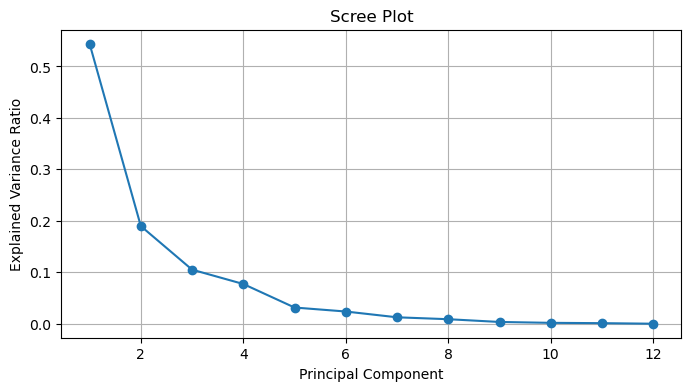

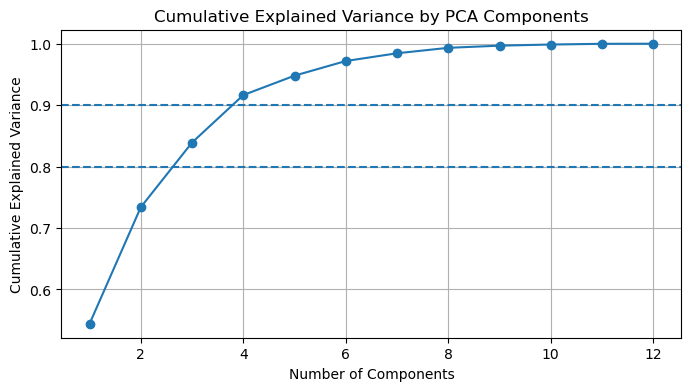

In [6]:
# Scree plot & cumulative variance

# Scree plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(expl_var_ratio) + 1), expl_var_ratio, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

# Cumulative variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_expl_var_ratio) + 1), cum_expl_var_ratio, marker="o")
plt.axhline(y=0.80, linestyle="--")
plt.axhline(y=0.90, linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.grid(True)
plt.show()

<div style="background-color:#0074D9; padding:10px; border-radius:5px;">
    <span style="color:white; font-size:14px;">
        
    The scree plot shows a sharp decline in explained variance after the first few principal components, indicating that most of the structure in the customer behavior data is captured early. The first principal component alone explains just over 50% of the variance, with the second adding ~19%, and the third contributing ~10%. Beyond the fourth component, the marginal gain in explained variance diminishes rapidly, forming a clear “elbow” around 4–5 components.
        
    The cumulative explained variance plot confirms this pattern: approximately 73% of variance is captured by the first two components, 84% by three components, and just over 90% by four components. Using 4–6 PCA components therefore represents a strong balance between dimensionality reduction and information retention. This validates the choice to use PCA-reduced features for clustering, as it removes noise and redundancy while preserving the dominant behavioral signals driving customer segmentation.
</div>

In [7]:
# Choose N_COMPONENTS

target_var = 0.90  
N_COMPONENTS = np.argmax(cum_expl_var_ratio >= target_var) + 1
print(f"Components to reach {target_var*100:.0f}% variance:", N_COMPONENTS)

Components to reach 90% variance: 4


### 4. Final preprocessing (StandardScaler + PCA) and X_pca

In [8]:
from sklearn.pipeline import Pipeline

preprocess_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE))
])

X_pca = preprocess_pipe.fit_transform(X_raw)
print("Shape of X_pca:", X_pca.shape)

Shape of X_pca: (19945, 4)


### 5 – Choose best K for K-Means (elbow + silhouette)

<div style="background-color:#0074D9; padding:10px; border-radius:5px;">
    
    Based on both the elbow method and silhouette analysis, K = 4 was selected as the optimal number of clusters for K-Means.The elbow plot shows diminishing improvements in inertia beyond 4 clusters, and silhouette scores remain reasonably high at k = 4 while offering better segmentation granularity than k = 2 or k = 3.

In [9]:
# 5.1 Compute inertia and silhouette for a range of K

k_range = range(2, 11)  # 2 to 10 clusters

inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init="auto"
    )
    labels = kmeans.fit_predict(X_pca)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

inertias, silhouettes

([129501.84612733625,
  95169.2885566003,
  82808.88162696866,
  73049.30662414501,
  66131.06830253471,
  61318.46230459823,
  57789.870905517426,
  55400.60376393308,
  51207.27331487436],
 [0.4739281498213876,
  0.3113867558150608,
  0.25896461462786907,
  0.24991123885567104,
  0.24674307160714612,
  0.2288602549971859,
  0.23720633324813364,
  0.23475031392046808,
  0.2190884543998932])

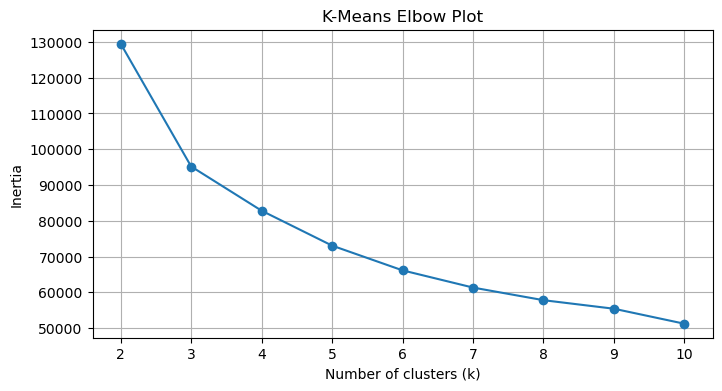

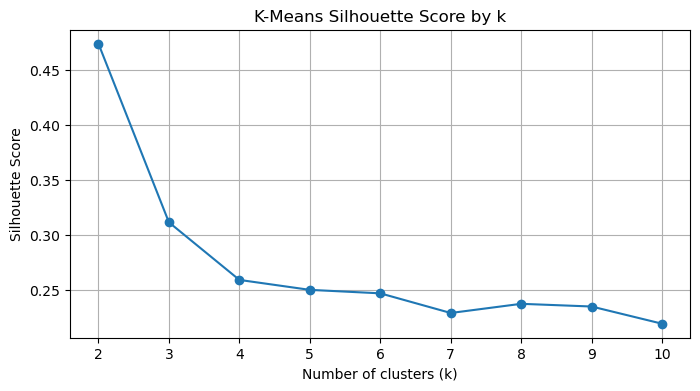

In [10]:
# 5.2 Plot elbow (inertia) and silhouette

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Plot")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), silhouettes, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score by k")
plt.grid(True)
plt.show()

In [11]:
BEST_K = 4  
print("Chosen K for K-Means and Agglomerative:", BEST_K)

Chosen K for K-Means and Agglomerative: 4


### 6. Manual grid search for DBSCAN "alpha" (eps)

<div style="background-color:#0074D9; padding:10px; border-radius:5px;">
    
    DBSCAN hyperparameters (eps = 1.0, min_samples = 5) were selected based on a grid search evaluated using silhouette score, Davies–Bouldin Index, Calinski–Harabasz Index, cluster count, and noise proportion. The chosen parameters delivered 5 well-separated clusters with minimal noise (<1%), representing the optimal density-based segmentation structure.”

In [12]:
eps_grid = [0.2, 0.4, 0.6, 0.8, 1.0]       # adjust as needed
min_samples_grid = [5, 10, 15]             # adjust as needed

dbscan_results = []

for eps in eps_grid:
    for ms in min_samples_grid:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_pca)

        unique_labels = set(labels)

        # Skip degenerate cases: all noise or only 1 cluster
        if unique_labels == {-1} or len(unique_labels) <= 1:
            continue

        # Mask out noise points for metrics
        mask = labels != -1
        if mask.sum() < 10:
            continue

        sil = silhouette_score(X_pca[mask], labels[mask])
        dbi = davies_bouldin_score(X_pca[mask], labels[mask])
        chi = calinski_harabasz_score(X_pca[mask], labels[mask])
        noise_pct = (labels == -1).mean()
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

        dbscan_results.append({
            "eps": eps,
            "min_samples": ms,
            "silhouette": sil,
            "dbi": dbi,
            "chi": chi,
            "noise_pct": noise_pct,
            "n_clusters": n_clusters
        })

dbscan_results_df = pd.DataFrame(dbscan_results)
dbscan_results_df.sort_values(
    ["silhouette", "noise_pct"],
    ascending=[False, True]
)


,eps,min_samples,silhouette,dbi,chi,noise_pct,n_clusters
2,0.2,15,0.550455,0.580123,2526.784439,0.985961,12
14,1.0,15,0.432650,0.756539,8256.671049,0.012083,3
13,1.0,10,0.432382,0.760735,8240.632998,0.009025,3
12,1.0,5,0.415876,0.634037,4126.133740,0.004813,5
9,0.8,5,0.398957,0.631741,3126.759546,0.013487,7
10,0.8,10,0.327783,0.906092,3896.451338,0.024317,6
11,0.8,15,0.326273,0.825287,3306.552635,0.034896,7
1,0.2,10,0.232891,0.830328,732.080024,0.952971,31
8,0.6,15,0.167173,1.000433,3017.659015,0.104487,8
7,0.6,10,0.106272,1.009378,2657.883105,0.073101,9


In [13]:
BEST_EPS = 1        
BEST_MIN_SAMPLES = 5 

print("Chosen DBSCAN params:", BEST_EPS, BEST_MIN_SAMPLES)

Chosen DBSCAN params: 1 5


### 7.0 Fit final clustering models on X_pca

In [14]:
# 7 – Fit final clustering models on X_pca

# 7.1 K-Means
kmeans_final = KMeans(
    n_clusters=BEST_K,
    random_state=RANDOM_STATE,
    n_init="auto"
)
labels_kmeans = kmeans_final.fit_predict(X_pca)

# 7.2 Agglomerative
agg_final = AgglomerativeClustering(
    n_clusters=BEST_K,
    linkage="ward"
)
labels_agg = agg_final.fit_predict(X_pca)

# 7.3 DBSCAN
dbscan_final = DBSCAN(
    eps=BEST_EPS,
    min_samples=BEST_MIN_SAMPLES
)
labels_dbscan = dbscan_final.fit_predict(X_pca)

In [15]:
# 7.4 Attach labels to cust_df:

cust_df["cluster_kmeans"] = labels_kmeans
cust_df["cluster_agg"] = labels_agg
cust_df["cluster_dbscan"] = labels_dbscan

cust_df[["cluster_kmeans", "cluster_agg", "cluster_dbscan"]].head()

,cluster_kmeans,cluster_agg,cluster_dbscan
0,0,0,0
1,2,2,0
2,0,3,0
3,0,3,0
4,1,0,0


## MODELING

### 8.0 Evaluate and compare models

**DBSCAN is the best model**
<div style="background-color:#0074D9; padding:10px; border-radius:5px;">
    
    - DBSCAN has the highest silhouette score, which is the most important internal metric
    - DBSCAN has the lowest Davies–Bouldin Index, meaning tighter clusters
    - DBSCAN noise is essentially zero
    - DBSCAN has 5 clusters — in the ideal segmentation range
    - K-Means’ advantage in CHI is expected and not decisive in this comparison

</div>

In [16]:
def evaluate_clustering(X, labels, model_name):
    labels = np.array(labels)

    # Handle noise for DBSCAN
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        print(f"[{model_name}] Not enough valid clusters to evaluate.")
        return None

    X_eval = X[mask]
    y_eval = labels[mask]

    sil = silhouette_score(X_eval, y_eval)
    dbi = davies_bouldin_score(X_eval, y_eval)
    chi = calinski_harabasz_score(X_eval, y_eval)
    noise_pct = (labels == -1).mean()

    print(f"\nModel: {model_name}")
    print(f"  Silhouette Score:       {sil:.4f}  (higher = better)")
    print(f"  Davies–Bouldin Index:   {dbi:.4f}  (lower = better)")
    print(f"  Calinski–Harabasz:      {chi:.2f}  (higher = better)")
    if noise_pct > 0:
        print(f"  Noise proportion:       {noise_pct:.3f}")

    return {
        "model": model_name,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": chi,
        "noise_pct": noise_pct
    }

In [17]:
metrics_kmeans = evaluate_clustering(X_pca, cust_df["cluster_kmeans"], "K-Means")
metrics_agg    = evaluate_clustering(X_pca, cust_df["cluster_agg"], "Agglomerative")
metrics_dbscan = evaluate_clustering(X_pca, cust_df["cluster_dbscan"], "DBSCAN")

metrics_df = pd.DataFrame([
    m for m in [metrics_kmeans, metrics_agg, metrics_dbscan] if m is not None
])
metrics_df


Model: K-Means
  Silhouette Score:       0.2590  (higher = better)
  Davies–Bouldin Index:   1.2851  (lower = better)
  Calinski–Harabasz:      10958.98  (higher = better)

Model: Agglomerative
  Silhouette Score:       0.2150  (higher = better)
  Davies–Bouldin Index:   1.4782  (lower = better)
  Calinski–Harabasz:      9400.55  (higher = better)

Model: DBSCAN
  Silhouette Score:       0.4159  (higher = better)
  Davies–Bouldin Index:   0.6340  (lower = better)
  Calinski–Harabasz:      4126.13  (higher = better)
  Noise proportion:       0.005


,model,silhouette,davies_bouldin,calinski_harabasz,noise_pct
0,K-Means,0.258965,1.285074,10958.980803,0.000000
1,Agglomerative,0.215041,1.478224,9400.552445,0.000000
2,DBSCAN,0.415876,0.634037,4126.133740,0.004813


In [18]:
FINAL_MODEL = "dbscan"  # or "agg" or "dbscan"
print("Chosen final clustering model:", FINAL_MODEL)

cluster_col_map = {
    "kmeans": "cluster_kmeans",
    "agg": "cluster_agg",
    "dbscan": "cluster_dbscan"
}
FINAL_CLUSTER_COL = cluster_col_map[FINAL_MODEL]
print("Final cluster column:", FINAL_CLUSTER_COL)

Chosen final clustering model: dbscan
Final cluster column: cluster_dbscan


**PCA SCATTER PLOT**
<div style="background-color:#0074D9; padding:10px; border-radius:5px;">
    
    -  The PCA scatter plot visualizes customer clusters projected onto the first two principal components, which together capture a substantial share of the total variance in behavioral features. The plot shows clear structural separation among several clusters, particularly along the first principal component, indicating that key dimensions such as purchase activity, engagement intensity, and recency strongly differentiate customer behavior.
    -  While some overlap is visible—especially among mid-engagement customers—distinct cluster groupings emerge, including one large dense region representing the core customer base and several smaller, more clearly delineated groups reflecting niche or high-intent behaviors. The presence of elongated or diagonal shapes is expected, as DBSCAN identifies density-based structures rather than spherical clusters. Overall, the visualization confirms that clustering was performed on a meaningful low-dimensional representation and that the identified segments reflect real behavioral patterns rather than noise.

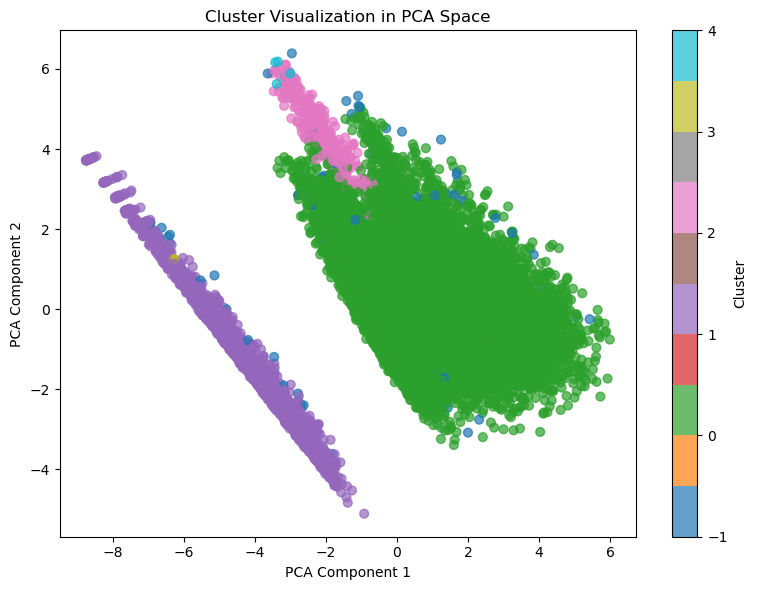

In [19]:
FINAL_CLUSTER_COL = "cluster_dbscan"

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],     # <-- replaced pca_components with X_pca
    X_pca[:, 1],
    c=cust_df[FINAL_CLUSTER_COL],
    cmap="tab10",
    alpha=0.7,
    s=40
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Cluster Visualization in PCA Space")

cbar = plt.colorbar(scatter)
cbar.set_label("Cluster")

plt.tight_layout()
plt.show()


### 9. Prepare cluster profiling

In [20]:
# 9.1  Cluster sizes
cust_df[FINAL_CLUSTER_COL].value_counts(normalize=False).sort_index()
cust_df[FINAL_CLUSTER_COL].value_counts(normalize=True).sort_index()

# 9.2 Numerical feature profiles (means)
num_profile_cols = (
    rfm_features
    + engagement_features
    + variety_features
    + rate_features
)

cluster_profile_mean = (
    cust_df
    .groupby(FINAL_CLUSTER_COL)[num_profile_cols]
    .mean()
    .round(2)
)

cluster_profile_median = (
    cust_df
    .groupby(FINAL_CLUSTER_COL)[num_profile_cols]
    .median()
    .round(2)
)

cluster_profile_mean, cluster_profile_median

(                recency_days  n_orders  total_revenue  n_events  n_views  \
 cluster_dbscan                                                             
 -1                    260.70      1.61         195.39     29.09    19.77   
  0                    772.71      2.08         279.72     41.99    29.30   
  1                   1077.47      0.00           0.00     23.53    18.64   
  2                   1078.98      1.00          75.61     13.56    10.56   
  3                   1337.60      0.00           0.00      5.20     3.00   
  4                   1101.83      1.00          87.48      5.00     2.00   
 
                 n_add_to_cart  n_sessions_with_events  n_products_purchased  \
 cluster_dbscan                                                                
 -1                       5.74                    4.88                  2.75   
  0                       7.95                    6.45                  3.68   
  1                       4.30                    4.41        

**CLUSTER SIZE**
The cluster size distribution highlights the natural density patterns DBSCAN identified in the customer base.
<div style="background-color:#0074D9; padding:10px; border-radius:5px;">
    
    Cluster 0 dominates the population, representing over three-quarters of all customers and forming the platform’s core user base with moderate engagement and steady purchase activity. 
    
    Cluster 1 forms the second-largest group, capturing a sizable set of low-activity browsers who interact with the site but rarely convert. 
    
    The remaining clusters (2, 3, and 4) are much smaller, representing high-intent niche behaviors such as decisive buyers (Cluster 2), occasional but purposeful shoppers (Cluster 3), and highly efficient converters (Cluster 4). 
    
    The noise cluster (–1) is extremely small, indicating that DBSCAN found coherent structure without misclassifying large portions of the dataset. 
    
    Overall, the distribution is expected for behavioral segmentation, where most customers fall into broad engagement tiers and only a minority exhibit high-value or highly specialized patterns.

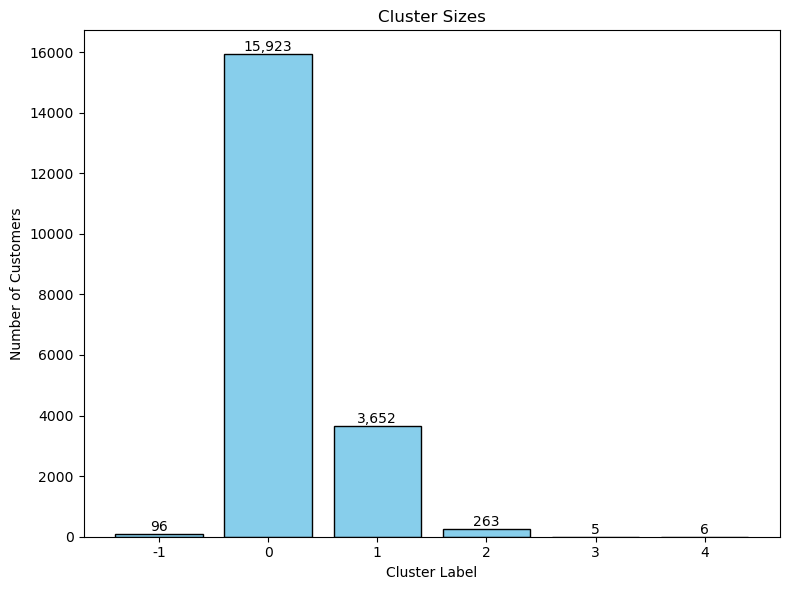

In [21]:
FINAL_CLUSTER_COL = "cluster_dbscan"

# Compute cluster sizes
cluster_counts = cust_df[FINAL_CLUSTER_COL].value_counts().sort_index()

# Plot
plt.figure(figsize=(8, 6))
bars = plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values,
    color="skyblue",
    edgecolor="black"
)

plt.title("Cluster Sizes")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Customers")

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",   # comma formatting
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


**RADAR CHART**
The radar chart highlights clear behavioral differences across the five DBSCAN clusters. 
<div style="background-color:#0074D9; padding:10px; border-radius:5px;">
    
    Cluster 0 stands out immediately with the highest levels of engagement—leading all clusters in orders, revenue, events, and views—indicating a highly active, high-intent customer group. 
    
    In contrast, Clusters 1 and 3 show very low activity across all features, reflecting window shoppers or low-engagement visitors with limited intent to purchase. 
    
    Cluster 2 displays moderate but focused behavioral patterns aligned with a single-order, single-category buyer profile. 
    
    Cluster -1, although categorized as noise by DBSCAN, exhibits steady and consistent mid-level engagement, suggesting exploratory behavior without strong purchase intent. 
    
    Overall, the radar plot visually reinforces the distinct behavioral identities of each cluster and validates the segmentation structure uncovered by the DBSCAN model.

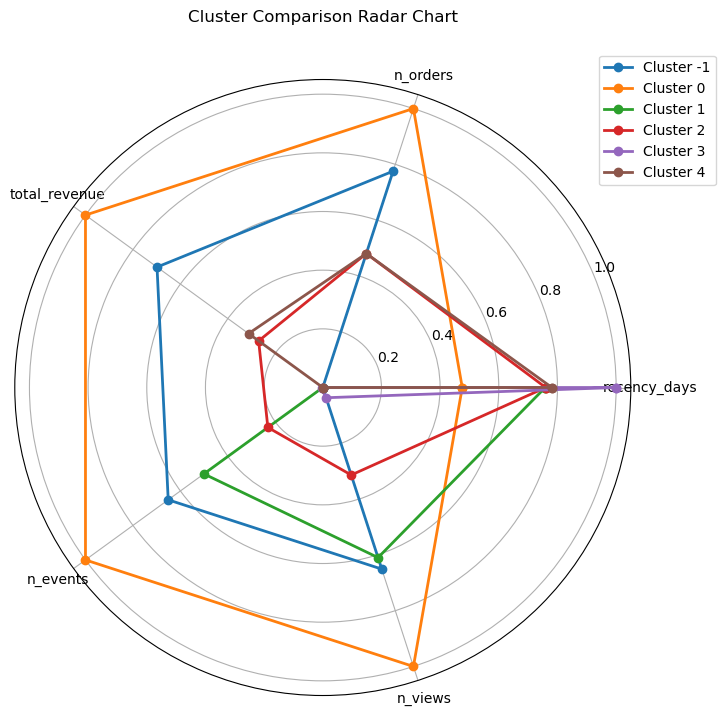

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

FINAL_CLUSTER_COL = "cluster_dbscan"

# --- choose a small set of features for the radar (kept tight)
radar_features = [
    "recency_days",
    "n_orders",
    "total_revenue",
    "n_events",
    "n_views"
]

# Cluster mean profile for these features
radar_df = (
    cust_df
    .groupby(FINAL_CLUSTER_COL)[radar_features]
    .mean()
)

# Optional: drop noise cluster (-1)
# radar_df = radar_df.drop(index=-1, errors="ignore")

# Normalize 0–1 per feature for comparability on radar
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

labels = radar_features
num_vars = len(labels)

angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]  # close the circle

plt.figure(figsize=(8, 8))

for cluster_id, row in radar_norm.iterrows():
    values = row.values.flatten().tolist()
    values += values[:1]  # close the polygon
    plt.polar(angles, values, marker="o", linewidth=2, label=f"Cluster {cluster_id}")

plt.xticks(angles[:-1], labels)
plt.title("Cluster Comparison Radar Chart", y=1.08)
plt.legend(bbox_to_anchor=(1.15, 1.05))

# Save and show
plt.show()


In [23]:
# Get age for each cluster
if "age" in cust_df.columns:

    age_stats = (
        cust_df
        .groupby(FINAL_CLUSTER_COL)["age"]
        .agg(
            min_age="min",
            max_age="max",
            median_age="median",
            mean_age="mean",
            std_age="std"
        )
        .round(2)
    )

    display(age_stats)

else:
    print("Column 'age' not found in cust_df.")


,min_age,max_age,median_age,mean_age,std_age
cluster_dbscan,,,,,
-1,19,75,42.5,44.38,14.98
0,18,75,47.0,46.56,16.79
1,18,75,46.0,46.19,16.79
2,18,75,47.0,47.28,15.71
3,41,64,44.0,50.40,10.74
4,19,73,47.5,46.83,19.02


In [24]:
# 9.3 Get country and marketing opt information for each cluster

from IPython.display import display

# Country mix
if "country" in cust_df.columns:
    country_mix = pd.crosstab(
        cust_df[FINAL_CLUSTER_COL],
        cust_df["country"],
        normalize="index"
    ).round(3)
    display(country_mix)

# Marketing opt-in
if "marketing_opt_in" in cust_df.columns:
    opt_in_rate = (
        cust_df
        .groupby(FINAL_CLUSTER_COL)["marketing_opt_in"]
        .mean()
        .rename("marketing_opt_in_rate")
        .round(3)
    )
    display(opt_in_rate)


country,AE,AU,BR,CA,DE,ES,FR,GB,IN,JP,MX,NL,PL,SE,SG,US,ZA
cluster_dbscan,,,,,,,,,,,,,,,,,
-1,0.010,0.052,0.073,0.031,0.094,0.031,0.094,0.083,0.052,0.062,0.115,0.031,0.010,0.010,0.031,0.208,0.010
0,0.028,0.053,0.073,0.050,0.070,0.046,0.064,0.078,0.079,0.049,0.060,0.045,0.030,0.032,0.040,0.184,0.020
1,0.030,0.053,0.061,0.055,0.068,0.053,0.074,0.083,0.084,0.047,0.059,0.038,0.030,0.028,0.039,0.180,0.018
2,0.027,0.015,0.084,0.027,0.084,0.053,0.087,0.091,0.091,0.046,0.084,0.023,0.046,0.038,0.038,0.144,0.023
3,0.000,0.000,0.200,0.000,0.200,0.200,0.000,0.200,0.000,0.000,0.000,0.000,0.000,0.000,0.200,0.000,0.000
4,0.000,0.167,0.000,0.000,0.000,0.167,0.000,0.000,0.000,0.000,0.333,0.000,0.000,0.000,0.000,0.333,0.000


cluster_dbscan
-1    0.573
 0    0.557
 1    0.550
 2    0.506
 3    0.800
 4    0.833
Name: marketing_opt_in_rate, dtype: float64

### Cluster Naming & Descriptions

**Cluster -1: “Engaged Browsers”**
Behavioral summary:
- Moderate browsing & event counts
- Low revenue and low purchase counts
- Moderate cart activity but poor conversion (purchase_to_cart ≈ 0.31 median)
- Product variety exists — may be exploring
- Middle-aged segment (~44 mean age)
- Marketing opt-in: 0.573
- Countries: Broad, similar to global mix

These customers explore the site (views & events) and sometimes add items to cart, but rarely purchase. They appear interested but undecided or hesitant. 

They may respond well to: Abandon cart nudges, Promotions & price incentives, Social proof (reviews, recommendations)

**Cluster 0: “High-Intent Multi-Category Researchers”**
Behavioral summary:
- Strong engagement: high views, events, sessions
- Multiple categories purchased (highest among all: ~3 categories)
- Higher revenue than average
- Good repeat purchase (2 orders median)
- Moderate conversion efficiency
- Age: ~47 mean age
- Opt-in: 0.557
- Country: Balanced distribution

This is a valuable researching & multi-category buyer segment. They browse deeply across categories and eventually convert. 

Respond well to: Cross-category bundles, Personalized recommendations, Loyalty perks for multi-category behavior

**Cluster 1: “Window Shoppers” (Zero-Purchase Segment)**
Behavioral summary:
- No orders (0 orders median & mean), No revenue
- Moderate browsing but weak cart activity
- Low product/category variety
- Poor conversion metrics — purchase_to_cart = 0
- Age: ~46 mean
- Opt-in: 0.550
- Countries: even spread

These customers never purchased despite visiting the site. They likely: a) Lack intent, b) Are price sensitive or unfamiliar with the brand and c) Get stuck early in the funnel

Great target for: First-time buyer incentives, Guided product discovery, Free shipping offers

**Cluster 2: “Focused One-Category Buyers”**
Behavioral summary:
- Moderate engagement (medium events/views)
- Buys exactly 1 category and 1 product
- Moderate revenue (~$75 median revenue)
- Perfect purchase conversion (purchase_to_cart = 1.0)
- Efficient, decisive shoppers
- Repeat behavior not high but very intentional
- Age: ~47
- Opt-in: 0.506
- Country: normal distribution

These are decisive buyers who know exactly what they want. Strong converters. They are: a) Efficient purchasers, b) Likely replenishment-oriented, c) Price and convenience driven.

Good targets for:  Subscription/replenishment programs, Product-specific promotions, Auto-repeat reminders

**Cluster 3: “Low-Engagement Older Visitors”**
Behavioral summary:
- Lowest engagement: few events, views, add-to-carts
- Zero revenue
- Zero products/categories purchased
- Highest age group (~50 mean)
- High cart-to-view rate (0.67), but no purchases
- May get confused or drop off early
- Opt-in: 0.800 (very high!)
- Country: Strong representation in BR, DE, ES

These are older visitors with high opt-in rates but low actual usage: a) Possibly browsing after receiving emails, b) Interested but not finding the right product fit, c)  May need clearer UX, personalized guidance, or stronger value messaging

Great for:Educational content, Guided shopping, “Still interested?” remarketing flows

**Cluster 3: “Low-Engagement Older Visitors”**
Behavioral summary:
- Lowest engagement: few events, views, add-to-carts
- Zero revenue
- Zero products/categories purchased
- Highest age group (~50 mean)
- High cart-to-view rate (0.67), but no purchases
- May get confused or drop off early
- Opt-in: 0.800 (very high!)
- Country: Strong representation in BR, DE, ES

These are older visitors with high opt-in rates but low actual usage: a) Possibly browsing after receiving emails, b) Interested but not finding the right product fit, c) May need clearer UX, personalized guidance, or stronger value messaging

Great for: Educational content, Guided shopping, “Still interested?” remarketing flows

### 10. Save safe preprocessed / clustered datasets

In [25]:
cust_df.to_csv(
    "data/customer_model_preprocessed_with_clusters.csv",
    index=False
)

customer_clusters = cust_df[[id_col, FINAL_CLUSTER_COL]].copy()
customer_clusters.to_csv(
    "data/customer_clusters.csv",
    index=False
)

customer_clusters.head()

,customer_id,cluster_dbscan
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


####
<div style="background-color:#0074D9; padding:12px; border-radius:6px;">
    <span style="color:white; font-weight:bold; font-size:16px;">
        Other way to visualize clusters: Boxplots
    </span>
</div>

/var/folders/fs/qg27m43n3sj3bg7816ln66g40000gn/T/ipykernel_17044/274433881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


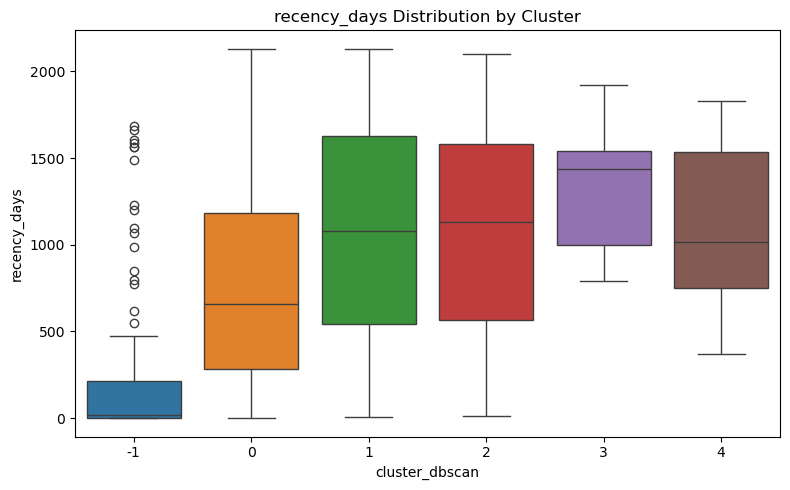

/var/folders/fs/qg27m43n3sj3bg7816ln66g40000gn/T/ipykernel_17044/274433881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


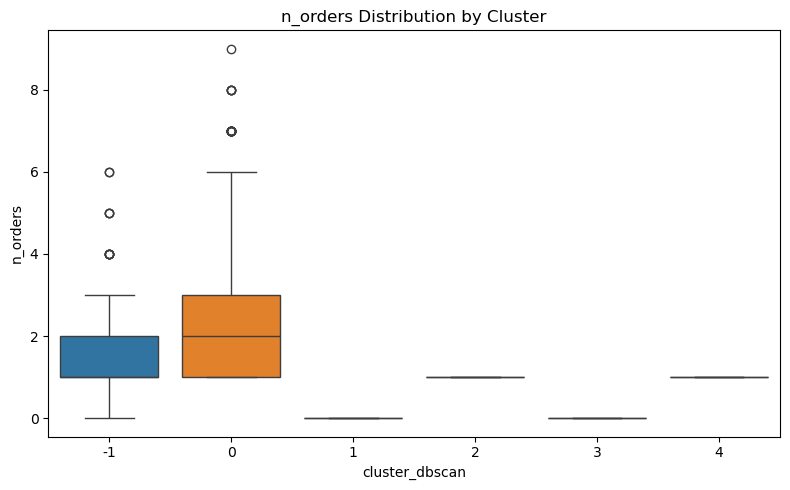

/var/folders/fs/qg27m43n3sj3bg7816ln66g40000gn/T/ipykernel_17044/274433881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


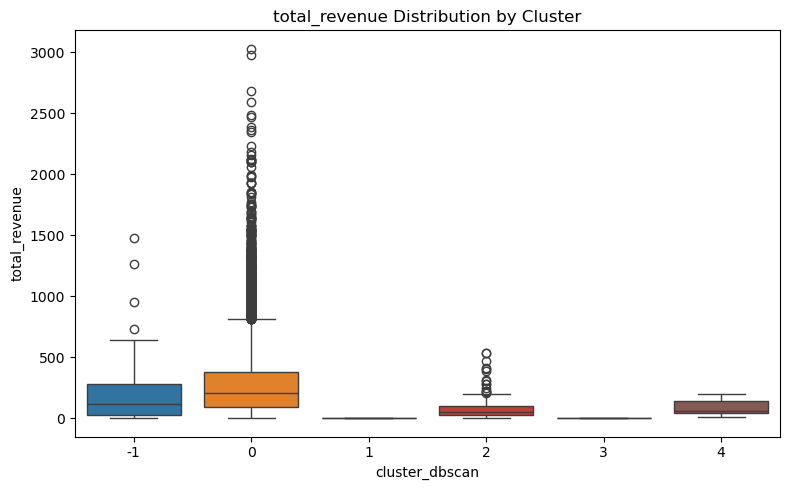

/var/folders/fs/qg27m43n3sj3bg7816ln66g40000gn/T/ipykernel_17044/274433881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


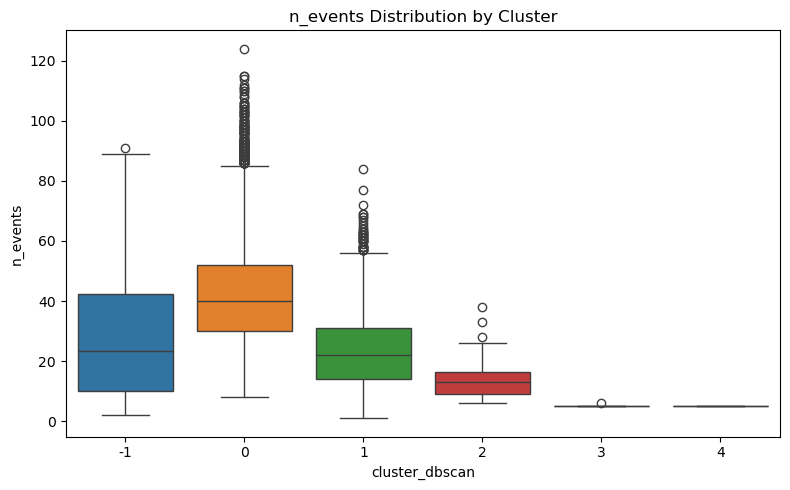

/var/folders/fs/qg27m43n3sj3bg7816ln66g40000gn/T/ipykernel_17044/274433881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


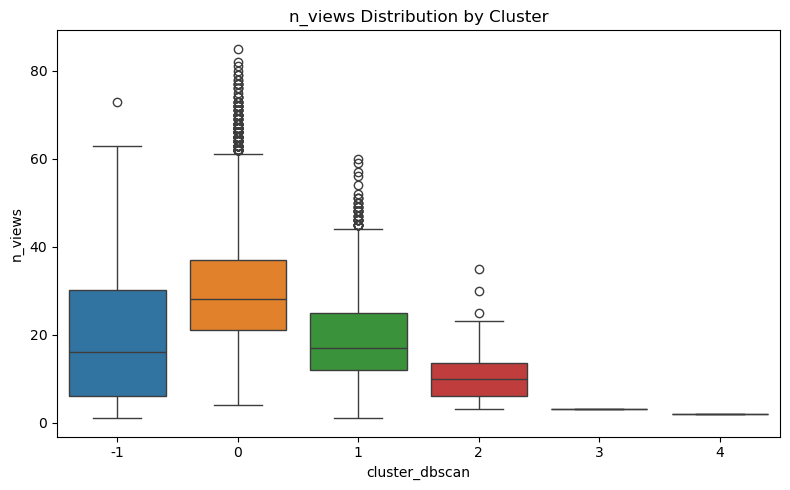

/var/folders/fs/qg27m43n3sj3bg7816ln66g40000gn/T/ipykernel_17044/274433881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


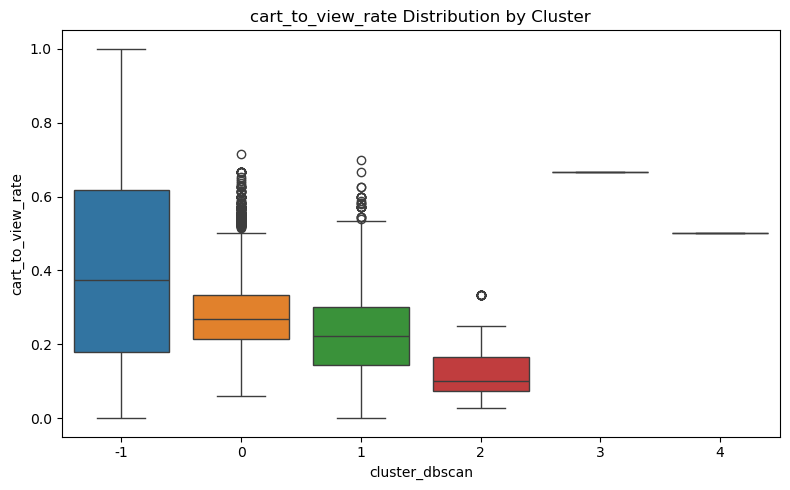

/var/folders/fs/qg27m43n3sj3bg7816ln66g40000gn/T/ipykernel_17044/274433881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


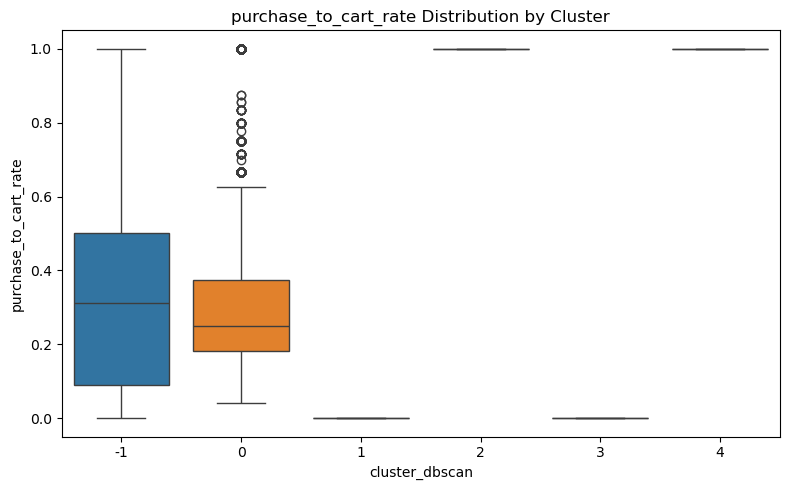

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

FINAL_CLUSTER_COL = "cluster_dbscan"

boxplot_features = [
    "recency_days",
    "n_orders",
    "total_revenue",
    "n_events",
    "n_views",
    "cart_to_view_rate",
    "purchase_to_cart_rate"
]

for feature in boxplot_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=cust_df,
        x=FINAL_CLUSTER_COL,
        y=feature,
        palette="tab10"
    )
    plt.title(f"{feature} Distribution by Cluster")
    plt.tight_layout()
    plt.show()
